In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import random

In [5]:
from google.colab import drive
drive.mount('/content/drive')
# !mkdir -p /content/drive/MyDrive/visdrone

Mounted at /content/drive


#### EDA частина

In [6]:
model = YOLO('yolov8n.pt')
model.val(data='VisDrone.yaml', imgsz=640)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'VisDrone.yaml' images not found, missing path '/content/datasets/VisDrone/images/val'
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 1.3Kfiles/s 0.8s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 1.4Kfiles/s 2.2s
WARNING ⚠️ Download failure, retrying 1/3 https://ultralytics.com/assets/VisDrone2019-DET-train.zip... ('Connection broken: IncompleteRead(1006352659 bytes read, 543522852 more expected)', IncompleteRead(1006352659 bytes read, 543522852 more expected))
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78af1ff37f80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

Створюю парсер датасету, зберігаю датасет локально на диску

In [7]:
# path = '/content/datasets/VisDrone/labels/train/'
# files_list = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

In [8]:
# col_name = ['image', 'class_id', 'xc', 'yc', 'w', 'h']
# data = []
# for file in files_list:
#     with open(os.path.join(path, file), "r", encoding='utf-8') as fname:
#         for line in fname:
#             parts = line.split()
#             if not parts:          # пропустити порожні рядки (буває в кінці файлів)
#                 continue
#             class_id = int(parts[0])
#             coords = [float(x) for x in parts[1:]]   # xc, yc, w, h → float
#             data.append([file, class_id] + coords)

# df = pd.DataFrame(data, columns=col_name)

In [9]:
# # мапінг id → назва класу (порядок з VisDrone.yaml)
# names = ['pedestrian','people','bicycle','car','van',
#          'truck','tricycle','awning-tricycle','bus','motor']

# df['class_name'] = df['class_id'].map(lambda i: names[i])

# df['area'] = df['w'] * df['h']

In [10]:
# print(df.shape)          # має бути ~340 тис. рядків для train
# print(df.dtypes)         # class_id=int, xc/yc/w/h/area=float, image/class_name=object
# df.head()

In [11]:
# df.to_parquet('/content/drive/MyDrive//ML for people/Final_project/visdrone/labels_train.parquet')

#### Підготовка візуалізацій

In [12]:
img_dir = '/content/datasets/VisDrone/images/train'
lbl_dir = '/content/datasets/VisDrone/labels/train'

names = ['pedestrian','people','bicycle','car','van',
         'truck','tricycle','awning-tricycle','bus','motor']

def show_image_with_boxes(img_filename):
    img_path = os.path.join(img_dir, img_filename)
    lbl_path = os.path.join(lbl_dir, img_filename.replace('.jpg', '.txt'))

    img = Image.open(img_path)
    W, H = img.size

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)

    # читаємо мітку і малюємо кожен бокс
    with open(lbl_path) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])

            # нормалізовані (0-1) -> пікселі
            xc, yc, w, h = xc*W, yc*H, w*W, h*H

            # центр+розмір -> лівий верхній кут
            x_min = xc - w/2
            y_min = yc - h/2

            # сам прямокутник
            rect = patches.Rectangle((x_min, y_min), w, h,
                                     linewidth=1, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            # підпис класу над боксом
            ax.text(x_min, y_min-2, names[cls], color='lime',
                    fontsize=7, weight='bold')

    ax.axis('off')
    plt.title(img_filename)
    # plt.savefig(os.path.join(fig_dir, 'sample.png'), bbox_inches='tight', dpi=150) # збереження знімків на диск за необхідності
    plt.show()

#### Visual 1
##### Приклади зображень з накладеними анотаціями

In [13]:
# прогнати на 3 випадкових зображеннях
all_imgs = os.listdir(img_dir)
for fn in random.sample(all_imgs, 3):
    show_image_with_boxes(fn)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
fig_dir = '/content/drive/MyDrive/ML for people/Final_project/visdrone/reports/figures'

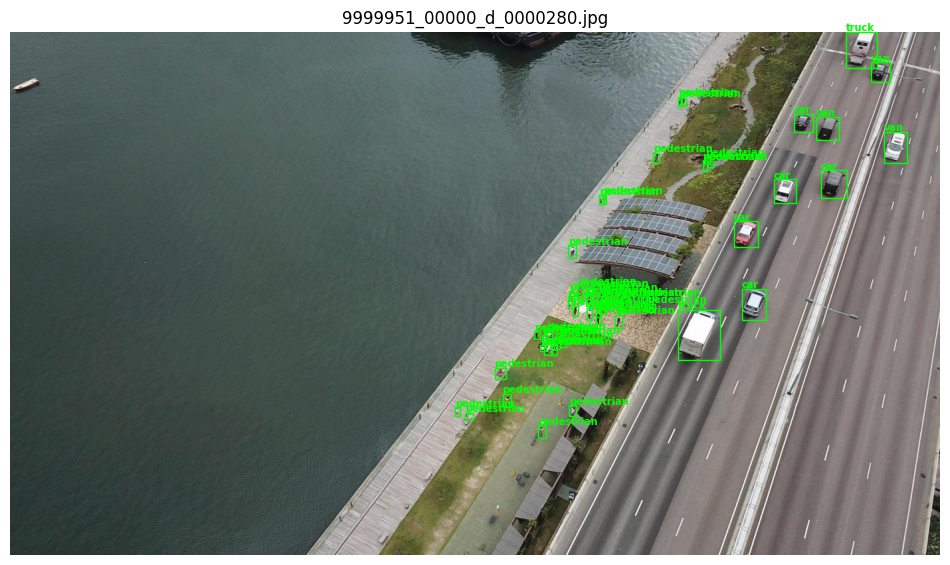

In [15]:
show_image_with_boxes('9999951_00000_d_0000280.jpg')

#### Висновки до Visual 1

1. Бокси об'єктів часто накладаються один на одного (дуже добре проілюстровано на останньому зображені). Проблема - модель може хибно визначати певні об'єкти як дублікати і видаляти їх, також довга обробка дублікатів.
2. Об'єкти плутаються між собою - car та van, bicycle i motor. Навіть людським оком тяжко відрізнити мотоцикл від велосипеда через розмір. Потрібна перевірка на confusion matrix.
На додачу people i pedestrian  плутаються між собою бо розрізнення йде за позою яке зверху важко розрізнити.
Частина класів VisDrone розрізняється за ознаками, які на аерознімку майже не видно - обмеження датасету.

3. Дисбаланс класів - клас tricycle знайшов лише після перегляду 12 випадкових зображень. Імовірно деякі класи об'єктів зустрічаються вкрай рідко.

#### Visual 2
##### Барплот кількості екземплярів по класах

In [16]:
df_path = '/content/drive/MyDrive/ML for people/Final_project/visdrone/labels_train.parquet'

df = pd.read_parquet(df_path)
df.head()

,image,class_id,xc,yc,w,h,class_name,area
0,9999969_00000_d_0000043.txt,0,0.564286,0.550476,0.012857,0.068571,pedestrian,0.000882
1,9999969_00000_d_0000043.txt,0,0.611786,0.485238,0.020714,0.061905,pedestrian,0.001282
2,9999969_00000_d_0000043.txt,0,0.544643,0.361905,0.010714,0.040000,pedestrian,0.000429
3,9999969_00000_d_0000043.txt,0,0.587143,0.310952,0.011429,0.037143,pedestrian,0.000425
4,9999969_00000_d_0000043.txt,0,0.486071,0.330952,0.007857,0.033333,pedestrian,0.000262


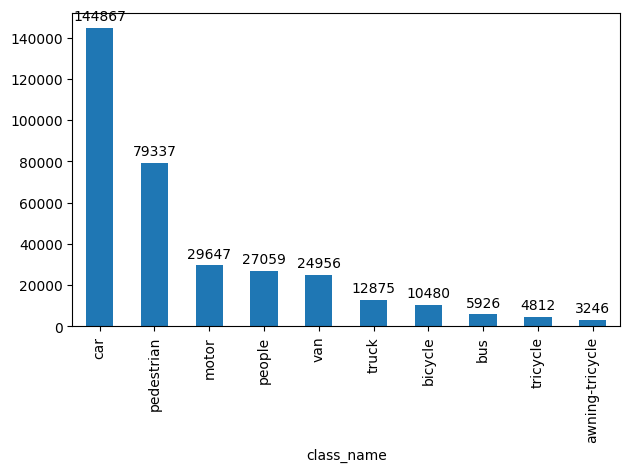

In [17]:
ax = df['class_name'].value_counts().plot(kind='bar')

ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'class_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

#### Висновок до Visual 2

car (144 867) до awning-tricycle (3 246) — це ~45:1. Модель значно краще вчиться розрізняти car аніж awning-tricycle. Це пояснює per-class AP в baseline моделі - awning-tricycle = 0.00002, car = 0.331

#### Visual 3

Гістограма кількості об'єктів на зображення

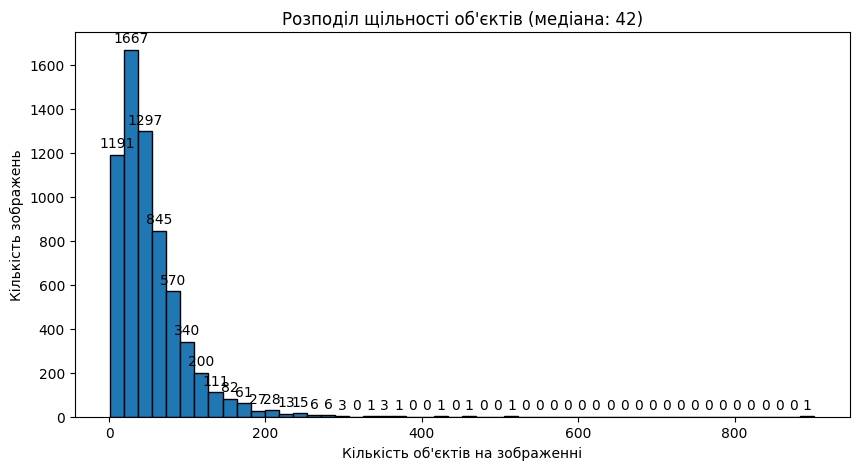

In [18]:
obj_per_img = df.groupby(['image']).size()

fig, ax = plt.subplots(figsize=(10, 5))
obj_per_img.plot(kind='hist', bins=50, ax=ax, edgecolor='black')

ax.set_xlabel('Кількість об\'єктів на зображенні')
ax.set_ylabel('Кількість зображень')
ax.set_title(f'Розподіл щільності об\'єктів (медіана: {obj_per_img.median():.0f})')

ax.bar_label(ax.containers[0], padding=3)

plt.savefig(os.path.join(fig_dir, 'objects_per_image.png'), bbox_inches='tight', dpi=150)
plt.show()

In [19]:
print(obj_per_img.describe())
print('Зображень з >100 об\'єктами:', (obj_per_img > 100).sum())
print('Максимум:', obj_per_img.max())

count    6471.000000
mean       53.037398
std        43.841912
min         1.000000
25%        24.000000
50%        42.000000
75%        70.000000
max       902.000000
dtype: float64
Зображень з >100 об'єктами: 703
Максимум: 902


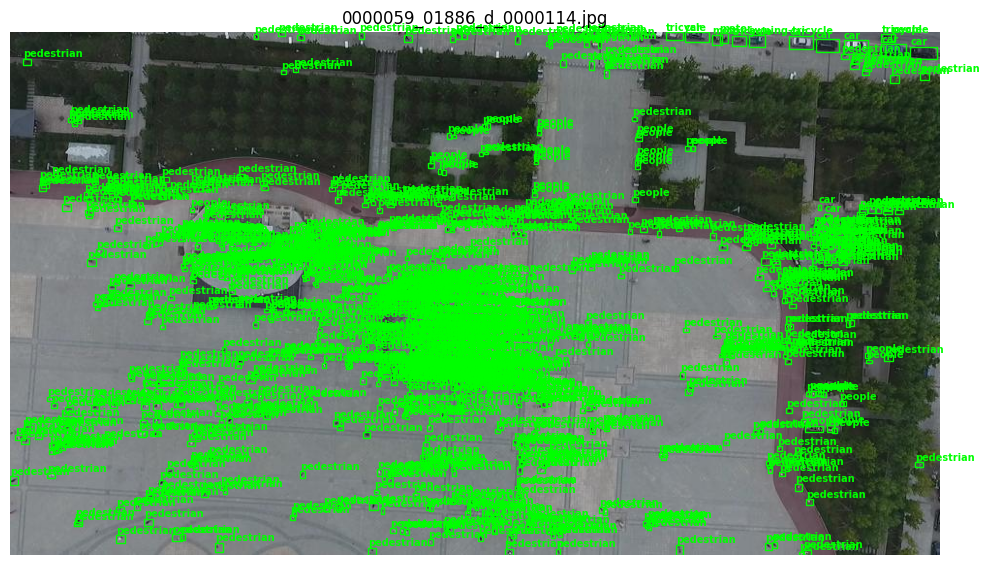

In [20]:
worst = obj_per_img.idxmax()
show_image_with_boxes(worst.replace('.txt', '.jpg'))

####Висновок до Visual 3

медіана 42 об'єкти проти ~7 у COCO — це у 6 разів щільніше. А 703 зображення (11% датасету) мають понад 100 об'єктів.

Кадри з хвоста розподілу створюють основне навантаження на NMS і є основним джерелом пропущених детекцій через злиття перекритих боксів.

#### Visual 4 розподіл площ bbox

In [21]:
# Витягую оригінальні розміри зображень
sizes = {}
for fn in os.listdir(img_dir):
    sizes[fn] = Image.open(os.path.join(img_dir, fn)).size   # (W, H), без декодування пікселів

size_df = pd.DataFrame([(k, v[0], v[1]) for k, v in sizes.items()],
                       columns=['image_jpg', 'W', 'H'])
print(size_df[['W','H']].value_counts())   # скільки унікальних роздільностей

W     H   
1400  1050    2498
      788     1299
2000  1500     772
1360  765      743
1916  1078     537
1920  1080     339
960   540      250
1398  1048      30
480   360        1
1344  756        1
1389  1042       1
Name: count, dtype: int64


In [22]:
size_df.to_parquet('/content/drive/MyDrive//ML for people/Final_project/visdrone/imgs_original_size.parquet')

In [23]:
size_df = pd.read_parquet('/content/drive/MyDrive//ML for people/Final_project/visdrone/imgs_original_size.parquet')

In [24]:
size_df.head()

,image_jpg,W,H
0,9999937_00000_d_0000154.jpg,1916,1078
1,9999964_00000_d_0000013.jpg,1400,1050
2,0000352_06469_d_0000572.jpg,1360,765
3,9999991_00000_d_0000018.jpg,1400,1050
4,0000342_00589_d_0000245.jpg,1360,765


In [25]:
size_df['image_jpg'] = size_df['image_jpg'].str.removesuffix('.jpg')
df['image'] = df['image'].str.removesuffix('.txt')

In [26]:
df_sizes = df.merge(size_df, left_on='image', right_on='image_jpg').drop(columns='image_jpg', axis=1)

# Обчислюємо оригінальні розмір боксів
df_sizes['area_px'] = df_sizes['w'] * df_sizes['h'] * df_sizes['W'] * df_sizes['H']

# Створюємо стовбець категорій
df_sizes['size_category'] = pd.cut(
    df_sizes['area_px'],
    bins=[0, 1024, 9216, float('inf')],
    labels=['small', 'medium', 'large']
)

In [27]:
df_sizes['size_category'].value_counts().reset_index()

,size_category,count
0,small,207604
1,medium,116622
2,large,18978


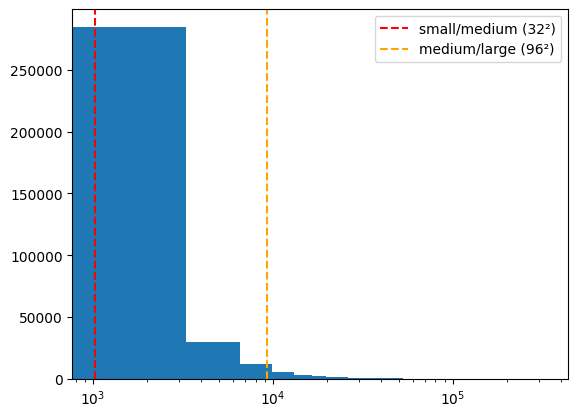

In [28]:
plt.hist(df_sizes['area_px'], bins=100)
plt.xscale('log')          # шкала логарифмічна, підписи — звичайні числа
plt.axvline(1024, color='r', linestyle='--', label='small/medium (32²)')
plt.axvline(9216, color='orange', linestyle='--', label='medium/large (96²)')
plt.legend()

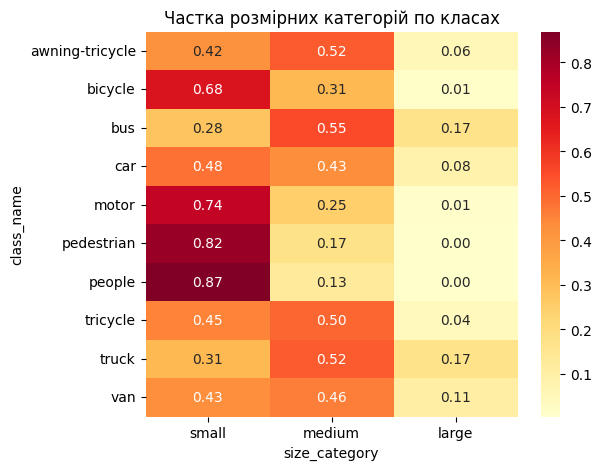

In [29]:
ct = pd.crosstab(df_sizes['class_name'], df_sizes['size_category'], normalize='index').round(3)

import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Частка розмірних категорій по класах')
plt.savefig(os.path.join(fig_dir, 'size_by_class.png'), bbox_inches='tight', dpi=150)
plt.show()

#### Висновок до Visual 4

60.5% об'єктів датасету належать до категорії small (<32² px за конвенцією COCO), тоді як large — лише 5.5%. При ресайзі до 640 px типовий small-об'єкт стискається до ~10×10 px і покривається 1–2 клітинками найдрібнішої сітки (stride 8), що близько до межі роздільної здатності архітектури. Це обґрунтовує гіпотезу H1: збільшення imgsz має дати непропорційний приріст саме на дрібних класах.

#### Visual 5 Heatmap центрів об'єктів у кадрі

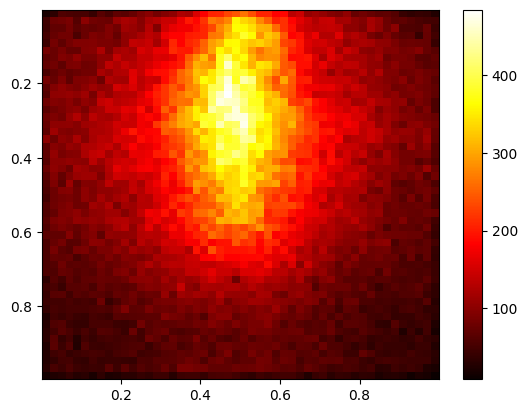

In [32]:
plt.hist2d(df['xc'], df['yc'], bins=50, cmap='hot')
plt.colorbar()
plt.gca().invert_yaxis()   # щоб верх зображення був зверху
plt.savefig(os.path.join(fig_dir, 'spatial_heatmap.png'))

#### Висновок до Visual 5

Концентрація обєктів в центрі і верхній частині кадру з поступовим зниженням кількості внизу зображень та з країв. Вочевидь повязано зі специфікою зйомки (камера з дрона зверху знімає вперед і під кутом).

## Висновки

Розподіл класів:
Дисбаланс сягає 45:1 (car vs awning-tricycle). Рідкісні класи (awning-tricycle, tricycle, bus) корелюють із найнижчим per-class AP — модель недостатньо їх "бачить" під час тренування.
Рідкісні класи страждають від дисбалансу, а дрібні/схожі (bicycle, tricycle) — ще й від нестачі візуальної інформації.

Розподіл щільності об'єктів:
Медіана 42 об'єкти/кадр проти ~7 у COCO; 11% зображень містять понад 100 об'єктів, максимум — 902. Це пояснює, чому постобробка (NMS, 4.7 ms) втричі перевищує час інференсу (1.8 ms), і створює системний ризик пропущених детекцій на щільних сценах через злиття перекритих боксів.

Частка розмірних категорій по класах:
Аналіз розподілу розмірів по класах виявляє другий, незалежний від дисбалансу фактор складності. Порівняння bicycle (10 480 екземплярів, 68% small, AP 0.0009) і bus (5 926 екземплярів, 28% small, AP 0.063) показує, що розмір об'єкта впливає на детектованість сильніше за частоту: попри вдвічі меншу представленість, bus детектується значно краще. Отже, стратегії покращення мають бути різними: для рідкісних-але-великих класів — балансування вибірки, для дрібних — підвищення роздільності входу.

Heatmap центрів об'єктів у кадрі
Просторовий розподіл нерівномірний: щільність у центрально-верхній частині кадру приблизно в 10 разів вища, ніж біля нижнього краю. Це наслідок операторської зйомки (наведення камери на об'єкт інтересу) та нахилу камери. Практичний наслідок: агресивні crop-аугментації ризикують вирізати саме інформативні зони, тому їх варто застосовувати обережно.